This notebook is a demo for the local Chan-Vese segmentation method for various kinds of images.

Copyright (c) 2025 Kevin Bui <kevinb3@uci.edu> and Adina Ciomaga <adina@math.univ-paris-diderot.fr>
 
This program is free software: you can redistribute it and/or modify it under the terms of the GNU Affero General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU Affero General Public License for more details.

You should have received a copy of the GNU Affero General Public License along
with this program. If not, see <http://www.gnu.org/licenses/>.

In [2]:
# import packages
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from skimage import segmentation
from lcv import *
from utils import *


In [3]:
# load image
vessel = Image.open('./images/grayscale_two_phase/vessel2.png')
vessel = np.array(vessel)/255

# set seed
np.random.seed(9999)

# add noise
noise = np.random.normal(0, 0.01, vessel.shape)
noisy_vessel = np.clip(vessel+noise,0,1)
noisy_vessel = rescale_image(noisy_vessel)
Image.fromarray(np.uint8(noisy_vessel*255)).save('check.png')


# Parameter: Lambda

Number of iterations completed: 11 
 

Number of iterations completed: 12 
 

Number of iterations completed: 16 
 



(-0.5, 30.5, 30.5, -0.5)

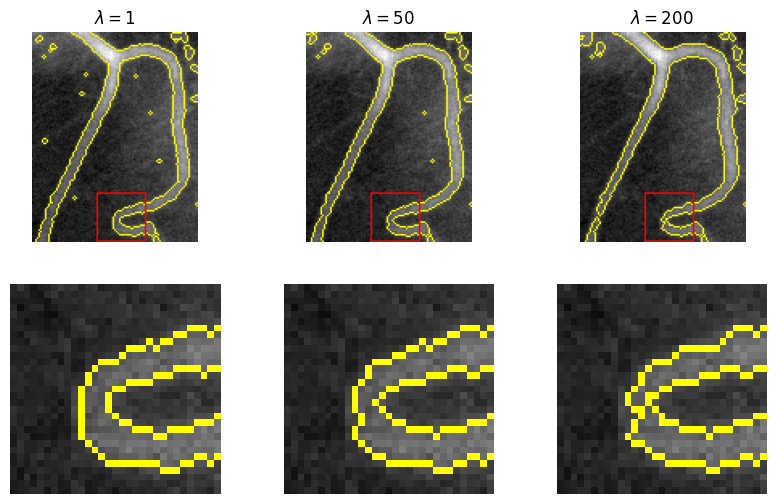

In [4]:
# lambda = 1
result_lambda1 = localtwophase(noisy_vessel, 1, 500, 20)
result_lambda1_edge = segmentation.mark_boundaries(noisy_vessel, result_lambda1.astype(int))
result_lambda1_edge2 = segmentation.mark_boundaries(rescale_image(noisy_vessel*255)[100:131, 40:71], result_lambda1[100:131, 40:71].astype(int))

# lambda = 50
result_lambda50 = localtwophase(noisy_vessel, 50, 500, 20)
result_lambda50_edge = segmentation.mark_boundaries(noisy_vessel, result_lambda50.astype(int))
result_lambda50_edge2 = segmentation.mark_boundaries(noisy_vessel[100:131, 40:71], result_lambda50[100:131, 40:71].astype(int))


# lambda = 200
result_lambda200 = localtwophase(noisy_vessel, 200, 500, 20)
result_lambda200_edge = segmentation.mark_boundaries(noisy_vessel, result_lambda200.astype(int))
result_lambda200_edge2 = segmentation.mark_boundaries(noisy_vessel[100:131, 40:71], result_lambda200[100:131, 40:71].astype(int))

# draw rectangle around close-up region
x1, y1 = 40, 100
x2,y2 = 70, 130

result_lambda1_edge = Image.fromarray(np.uint8(result_lambda1_edge*255))
draw = ImageDraw.Draw(result_lambda1_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_lambda50_edge = Image.fromarray(np.uint8(result_lambda50_edge*255))
draw = ImageDraw.Draw(result_lambda50_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_lambda200_edge = Image.fromarray(np.uint8(result_lambda200_edge*255))
draw = ImageDraw.Draw(result_lambda200_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)


# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_lambda1_edge)
plt.axis('off')
plt.title(r'$\lambda =1$')
plt.subplot(2,3,4)
plt.imshow(result_lambda1_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_lambda50_edge)
plt.axis('off')
plt.title(r'$\lambda =50$')
plt.subplot(2,3,5)
plt.imshow(result_lambda50_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_lambda200_edge)
plt.axis('off')
plt.title(r'$\lambda =200$')
plt.subplot(2,3,6)
plt.imshow(result_lambda200_edge2)
plt.axis('off')

# Parameter: Beta

Number of iterations completed: 24 
 

Number of iterations completed: 16 
 

Number of iterations completed: 12 
 



(-0.5, 30.5, 30.5, -0.5)

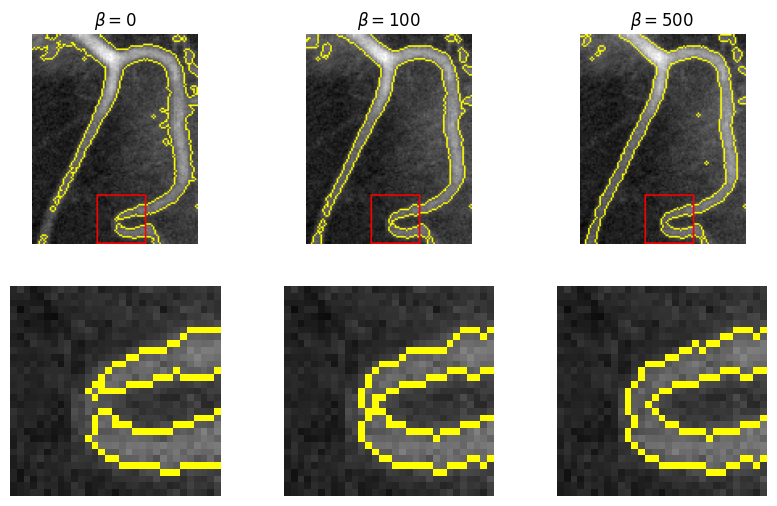

In [5]:
# beta = 0 
result_beta0 = localtwophase(noisy_vessel, 50, 0, 20)
result_beta0_edge = segmentation.mark_boundaries(noisy_vessel, result_beta0.astype(int))
result_beta0_edge2 = segmentation.mark_boundaries(noisy_vessel[100:131, 40:71], result_beta0[100:131, 40:71].astype(int))


# beta = 100
result_beta100 = localtwophase(noisy_vessel, 50, 100, 20)
result_beta100_edge = segmentation.mark_boundaries(noisy_vessel, result_beta100.astype(int))
result_beta100_edge2 = segmentation.mark_boundaries(noisy_vessel[100:131, 40:71], result_beta100[100:131, 40:71].astype(int))


# beta = 500
result_beta500 = localtwophase(noisy_vessel, 50, 500, 20)
result_beta500_edge = segmentation.mark_boundaries(noisy_vessel, result_beta500.astype(int))
result_beta500_edge2 = segmentation.mark_boundaries(noisy_vessel[100:131, 40:71], result_beta500[100:131, 40:71].astype(int))

# draw rectangle around close-up region
x1, y1 = 40, 100
x2,y2 = 70, 130

result_beta0_edge = Image.fromarray(np.uint8(result_beta0_edge*255))
draw = ImageDraw.Draw(result_beta0_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_beta100_edge = Image.fromarray(np.uint8(result_beta100_edge*255))
draw = ImageDraw.Draw(result_beta100_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_beta500_edge = Image.fromarray(np.uint8(result_beta500_edge*255))
draw = ImageDraw.Draw(result_beta500_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)


# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_beta0_edge)
plt.axis('off')
plt.title(r'$\beta =0$')
plt.subplot(2,3,4)
plt.imshow(result_beta0_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_beta100_edge)
plt.axis('off')
plt.title(r'$\beta =100$')
plt.subplot(2,3,5)
plt.imshow(result_beta100_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_beta500_edge)
plt.axis('off')
plt.title(r'$\beta =500$')
plt.subplot(2,3,6)
plt.imshow(result_beta500_edge2)
plt.axis('off')

# Parameter: dt

Number of iterations completed: 11 
 

Number of iterations completed: 12 
 

Number of iterations completed: 12 
 



(-0.5, 30.5, 30.5, -0.5)

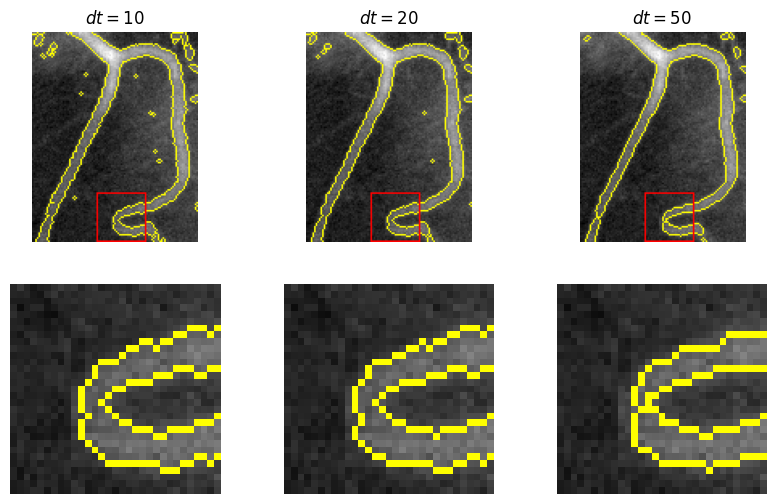

In [6]:
# dt = 10 
result_dt10 = localtwophase(noisy_vessel, 50, 500, 10)
result_dt10_edge = segmentation.mark_boundaries(noisy_vessel, result_dt10.astype(int))
result_dt10_edge2 = segmentation.mark_boundaries(noisy_vessel[100:131, 40:71], result_dt10[100:131, 40:71].astype(int))


# dt = 20
result_dt20 = localtwophase(noisy_vessel, 50, 500, 20)
result_dt20_edge = segmentation.mark_boundaries(noisy_vessel, result_dt20.astype(int))
result_dt20_edge2 = segmentation.mark_boundaries(noisy_vessel[100:131, 40:71], result_dt20[100:131, 40:71].astype(int))


# dt = 50
result_dt50 = localtwophase(noisy_vessel, 50, 500, 50)
result_dt50_edge = segmentation.mark_boundaries(noisy_vessel, result_dt50.astype(int))
result_dt50_edge2 = segmentation.mark_boundaries(noisy_vessel[100:131, 40:71], result_dt50[100:131, 40:71].astype(int))

# draw rectangles around close-up regions
x1, y1 = 40, 100
x2,y2 = 70, 130

result_dt10_edge = Image.fromarray(np.uint8(result_dt10_edge*255))
draw = ImageDraw.Draw(result_dt10_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_dt20_edge = Image.fromarray(np.uint8(result_dt20_edge*255))
draw = ImageDraw.Draw(result_dt20_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_dt50_edge = Image.fromarray(np.uint8(result_dt50_edge*255))
draw = ImageDraw.Draw(result_dt50_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)


# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_dt10_edge)
plt.axis('off')
plt.title(r'$dt =10$')
plt.subplot(2,3,4)
plt.imshow(result_dt10_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_dt20_edge)
plt.axis('off')
plt.title(r'$dt = 20$')
plt.subplot(2,3,5)
plt.imshow(result_dt20_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_dt50_edge)
plt.axis('off')
plt.title(r'$dt=50$')
plt.subplot(2,3,6)
plt.imshow(result_dt50_edge2)
plt.axis('off')